In [1]:
# ============================================================
#  03 · BASELINE MODELS — SENTIMENT ALLOCINE
#  Auteur   : [Ton Nom]
#  Date     : 2025
#  Objectif : Établir des modèles de référence robustes,
#             comparés rigoureusement, calibrés et sauvegardés
#             en vue du déploiement en production.
# ============================================================

# ── Stdlib ──────────────────────────────────────────────────
import sys
import json
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Numérique ────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn ─────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score,
    classification_report, confusion_matrix,
    RocCurveDisplay,
)
import joblib

# ── Optuna ───────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Chemins projet ───────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH    = PROJECT_ROOT / "data" / "processed"
MODEL_DIR    = PROJECT_ROOT / "models" / "baseline"
REPORTS_DIR  = PROJECT_ROOT / "reports" / "figures"
METRICS_DIR  = PROJECT_ROOT / "reports" / "metrics"

for d in [MODEL_DIR, REPORTS_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Reproductibilité ─────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Style global des figures ─────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})
SNS_PALETTE = "Blues_d"

print(f"   Environnement prêt | ROOT : {PROJECT_ROOT}")
print(f"   MODEL_DIR   : {MODEL_DIR}")
print(f"   REPORTS_DIR : {REPORTS_DIR}")

   Environnement prêt | ROOT : /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine
   MODEL_DIR   : /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine/models/baseline
   REPORTS_DIR : /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine/reports/figures


In [5]:
# ============================================================
#  SECTION 2 — ÉVALUATION STANDARDISÉE
#  Toute la mesure de performance passe par ces fonctions.
#  Cela garantit une comparaison équitable entre modèles.
# ============================================================

def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    """
    Calcule l'ensemble des métriques pour un modèle donné.
    y_proba : probabilités de la classe positive (optionnel).
    """
    metrics = {
        "accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "f1":        round(f1_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred), 4),
        "recall":    round(recall_score(y_true, y_pred), 4),
    }
    if y_proba is not None:
        metrics["roc_auc"] = round(roc_auc_score(y_true, y_proba), 4)
    else:
        metrics["roc_auc"] = None
    return metrics


def get_proba_safe(model, X) -> np.ndarray | None:
    """
    Retourne les probabilités si disponibles, sinon None.
    LinearSVC n'a pas predict_proba nativement — on retourne None
    sauf s'il a été calibré.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return None


def evaluate_and_store(
    name: str,
    model,
    X_test: pd.Series,
    y_test: pd.Series,
    threshold: float = 0.5,
    store: list = None,
) -> dict:
    """
    Évalue un modèle, affiche son rapport et stocke ses métriques.

    Parameters
    ----------
    name      : label du modèle
    model     : pipeline sklearn entraîné
    X_test    : textes de test
    y_test    : labels de test
    threshold : seuil de décision (défaut 0.5)
    store     : liste dans laquelle ajouter le résultat

    Returns
    -------
    dict contenant toutes les métriques
    """
    y_proba = get_proba_safe(model, X_test)

    if y_proba is not None:
        y_pred = (y_proba >= threshold).astype(int)
    else:
        y_pred = model.predict(X_test)

    metrics = compute_metrics(y_test, y_pred, y_proba)
    metrics["model"]     = name
    metrics["threshold"] = threshold

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    for k, v in metrics.items():
        if k not in ("model", "threshold") and v is not None:
            print(f"  {k:<12}: {v:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Négatif','Positif'])}")

    if store is not None:
        store.append(metrics)

    return metrics


# Registre global — toutes les performances atterrissent ici
RESULTS: list[dict] = []

In [6]:
# ============================================================
#  SECTION 3 — DÉFINITION DES MODÈLES CANDIDATS
#
#  Chaque modèle est une Pipeline sklearn :
#    TfidfVectorizer  →  Classifier
#
#  Choix techniques :
#  - sublinear_tf=True  : atténue l'effet des mots très fréquents
#  - ngram_range=(1,2)  : capture les bigrammes (ex: "pas bon")
#  - min_df=2           : ignore les hapax légomenons
#  - LinearSVC          : meilleur que SVC(kernel=linear) sur grands corpus
#  - MultinomialNB      : requiert des valeurs ≥ 0 → TF-IDF compatible
# ============================================================

TFIDF_SHARED = dict(
    max_features=80_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.97,
    sublinear_tf=True,
)

CANDIDATE_MODELS: dict[str, Pipeline] = {

    "LogReg": Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_SHARED)),
        ("clf",   LogisticRegression(
            C=1.0,
            solver="saga",
            max_iter=2000,
            n_jobs=-1,
            random_state=SEED,
        )),
    ]),

    "LinearSVC": Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_SHARED)),
        ("clf",   LinearSVC(
            C=1.0,
            max_iter=3000,
            random_state=SEED,
        )),
    ]),

    "NaiveBayes": Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_SHARED)),
        ("clf",   MultinomialNB(alpha=0.5)),
    ]),
}

print("  Modèles candidats définis :")
for name in CANDIDATE_MODELS:
    print(f"   · {name}")

  Modèles candidats définis :
   · LogReg
   · LinearSVC
   · NaiveBayes


In [9]:
# ============================================================
#  SECTION X — CHARGEMENT DES DONNÉES (PARQUET)
# ============================================================

# ── Chargement ───────────────────────────────────────────────
train_df = pd.read_parquet(DATA_PATH / "train.parquet")
val_df   = pd.read_parquet(DATA_PATH / "validation.parquet")
test_df  = pd.read_parquet(DATA_PATH / "test.parquet")

# ── Choix des colonnes (IMPORTANT) ───────────────────────────
TEXT_COL   = "text_classical"   # optimisé pour TF-IDF
TARGET_COL = "label"

# ── Définition des datasets ──────────────────────────────────
X_train = train_df[TEXT_COL]
y_train = train_df[TARGET_COL].astype(int)

X_val = val_df[TEXT_COL]
y_val = val_df[TARGET_COL].astype(int)

X_test = test_df[TEXT_COL]
y_test = test_df[TARGET_COL].astype(int)

# ── Vérifications robustes ───────────────────────────────────
assert X_train.isna().sum() == 0, "NaN dans X_train"
assert y_train.isna().sum() == 0, "NaN dans y_train"

print(f"Train : {X_train.shape[0]} samples")
print(f"Val   : {X_val.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")

print("\nDistribution train :")
print(y_train.value_counts(normalize=True))

Train : 160000 samples
Val   : 20000 samples
Test  : 20000 samples

Distribution train :
label
1    0.503669
0    0.496331
Name: proportion, dtype: float64


In [10]:
# ============================================================
#  SECTION 4 — ENTRAÎNEMENT DES BASELINES (CONFIGS PAR DÉFAUT)
#
#  On entraîne d'abord chaque modèle avec ses hyperparamètres
#  par défaut. Cela donne une première mesure honnête avant
#  toute optimisation.
# ============================================================

TRAINED_MODELS: dict[str, Pipeline] = {}
TRAIN_TIMES:    dict[str, float]    = {}

for name, pipeline in CANDIDATE_MODELS.items():
    print(f"\n Entraînement : {name} ...", end=" ", flush=True)
    t0 = time.time()

    pipeline.fit(X_train, y_train)

    elapsed = round(time.time() - t0, 2)
    TRAINED_MODELS[name] = pipeline
    TRAIN_TIMES[name]    = elapsed

    print(f"  ({elapsed}s)")
    evaluate_and_store(
        name=f"{name} (défaut)",
        model=pipeline,
        X_test=X_test,
        y_test=y_test,
        store=RESULTS,
    )

print("\n\n Entraînement baselines terminé.")


 Entraînement : LogReg ...   (132.27s)

  LogReg (défaut)
  accuracy    : 0.9401
  f1          : 0.9377
  precision   : 0.9351
  recall      : 0.9404
  roc_auc     : 0.9857

              precision    recall  f1-score   support

     Négatif       0.94      0.94      0.94     10408
     Positif       0.94      0.94      0.94      9592

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000


 Entraînement : LinearSVC ...   (125.02s)

  LinearSVC (défaut)
  accuracy    : 0.9410
  f1          : 0.9387
  precision   : 0.9350
  recall      : 0.9426

              precision    recall  f1-score   support

     Négatif       0.95      0.94      0.94     10408
     Positif       0.93      0.94      0.94      9592

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000


 Entraînemen

  Optimisation Optuna — LogReg (30 trials) ...


Best trial: 21. Best value: 0.939633: 100%|██████████████████████████████████████████████████████████████████████████| 30/30 [1:02:59<00:00, 125.97s/it]



  Optimisation terminée en 3779.0s
   Meilleur F1 (CV) : 0.9396
   Meilleurs params : {'max_features': 100000, 'ngram_max': 2, 'min_df': 4, 'max_df': 0.8671638649627287, 'C': 5.286516485491993, 'solver': 'saga'}


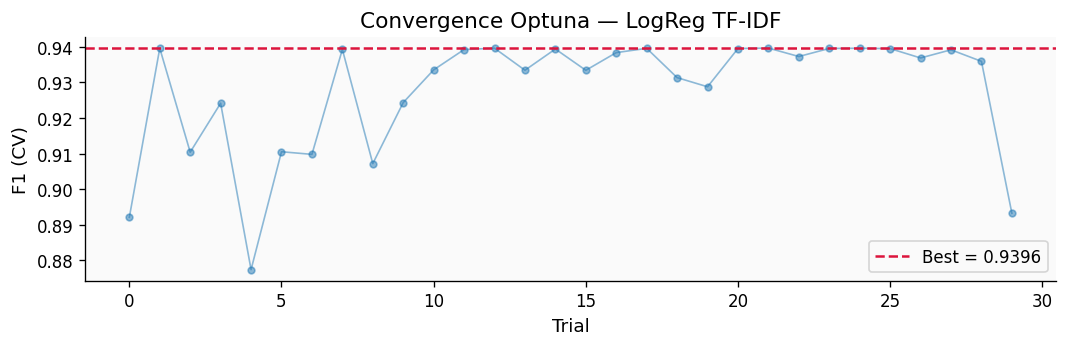

In [48]:
# ============================================================
#  SECTION 5 — OPTIMISATION BAYÉSIENNE (OPTUNA)
#
#  On optimise LogReg en priorité : c'est le modèle le plus
#  interprétable et généralement le meilleur en NLP classique.
#
#  Stratégie :
#  - Validation croisée stratifiée (3 folds) sur le train
#  - Métrique cible : F1 macro
#  - 30 trials : bon compromis vitesse / qualité
# ============================================================

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)


def objective_logreg(trial: optuna.Trial) -> float:
    """Fonction objectif Optuna pour LogReg + TF-IDF."""
    config = {
        "max_features":  trial.suggest_int("max_features", 50_000, 150_000, step=10_000),
        "ngram_max":     trial.suggest_int("ngram_max", 1, 2),
        "min_df":        trial.suggest_int("min_df", 1, 5),
        "max_df":        trial.suggest_float("max_df", 0.85, 0.99),
        "C":             trial.suggest_float("C", 0.01, 10.0, log=True),
        "solver":        trial.suggest_categorical("solver", ["saga", "lbfgs"]),
    }

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=config["max_features"],
            ngram_range=(1, config["ngram_max"]),
            min_df=config["min_df"],
            max_df=config["max_df"],
            sublinear_tf=True,
        )),
        ("clf", LogisticRegression(
            C=config["C"],
            solver=config["solver"],
            max_iter=2000,
            n_jobs=-1,
            random_state=SEED,
        )),
    ])

    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv, scoring="f1", n_jobs=-1,
    )
    return scores.mean()


print("  Optimisation Optuna — LogReg (30 trials) ...")
t0 = time.time()

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective_logreg, n_trials=30, show_progress_bar=True)

elapsed_opt = round(time.time() - t0, 1)
print(f"\n  Optimisation terminée en {elapsed_opt}s")
print(f"   Meilleur F1 (CV) : {study.best_value:.4f}")
print(f"   Meilleurs params : {study.best_params}")

# ── Visualisation convergence ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
trials_df = study.trials_dataframe()
ax.plot(trials_df.index, trials_df["value"], "o-", alpha=0.5, ms=4, lw=1)
ax.axhline(study.best_value, color="crimson", ls="--", lw=1.5,
           label=f"Best = {study.best_value:.4f}")
ax.set_xlabel("Trial")
ax.set_ylabel("F1 (CV)")
ax.set_title("Convergence Optuna — LogReg TF-IDF")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "optuna_convergence.png", bbox_inches="tight")
plt.show()

In [49]:
def objective_svc(trial: optuna.Trial) -> float:
    """Fonction objectif Optuna pour LinearSVC + TF-IDF."""
    config = {
        "max_features": trial.suggest_int("max_features", 50_000, 150_000, step=10_000),
        "ngram_max":    trial.suggest_int("ngram_max", 1, 2),
        "min_df":       trial.suggest_int("min_df", 1, 5),
        "max_df":       trial.suggest_float("max_df", 0.85, 0.99),
        "C":            trial.suggest_float("C", 0.01, 10.0, log=True),
    }

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=config["max_features"],
            ngram_range=(1, config["ngram_max"]),
            min_df=config["min_df"],
            max_df=config["max_df"],
            sublinear_tf=True,
        )),
        ("clf", LinearSVC(
            C=config["C"],
            max_iter=3000,
            random_state=SEED,
        )),
    ])

    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv, scoring="f1", n_jobs=-1,
    )
    return scores.mean()


print("  Optimisation Optuna — LinearSVC (30 trials) ...")
study_svc = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_svc.optimize(objective_svc, n_trials=30, show_progress_bar=True)

print(f"\n  Meilleur F1 (CV) : {study_svc.best_value:.4f}")
print(f"   Meilleurs params : {study_svc.best_params}")


  Optimisation Optuna — LinearSVC (30 trials) ...


Best trial: 29. Best value: 0.940253: 100%|████████████████████████████████████████████████████████████████████████████| 30/30 [59:00<00:00, 118.02s/it]


  Meilleur F1 (CV) : 0.9403
   Meilleurs params : {'max_features': 100000, 'ngram_max': 2, 'min_df': 4, 'max_df': 0.9641147350191699, 'C': 0.33333757386947294}


In [51]:
def objective_nb(trial: optuna.Trial) -> float:
    """Fonction objectif Optuna pour Naive Bayes + TF-IDF."""
    config = {
        "max_features": trial.suggest_int("max_features", 50_000, 150_000, step=10_000),
        "ngram_max":    trial.suggest_int("ngram_max", 1, 2),
        "min_df":       trial.suggest_int("min_df", 1, 5),
        "max_df":       trial.suggest_float("max_df", 0.85, 0.99),
        "alpha":        trial.suggest_float("alpha", 0.1, 2.0),
    }

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=config["max_features"],
            ngram_range=(1, config["ngram_max"]),
            min_df=config["min_df"],
            max_df=config["max_df"],
            sublinear_tf=True,
        )),
        ("clf", MultinomialNB(alpha=config["alpha"])),
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    return scores.mean()


print("  Optimisation Optuna — NaiveBayes (30 trials) ...")
study_nb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_nb.optimize(objective_nb, n_trials=30, show_progress_bar=True)

print(f"\n  Meilleur F1 (CV) : {study_nb.best_value:.4f}")
print(f"   Meilleurs params : {study_nb.best_params}")


  Optimisation Optuna — NaiveBayes (30 trials) ...


Best trial: 21. Best value: 0.921218: 100%|████████████████████████████████████████████████████████████████████████████| 30/30 [54:12<00:00, 108.43s/it]


  Meilleur F1 (CV) : 0.9212
   Meilleurs params : {'max_features': 150000, 'ngram_max': 2, 'min_df': 2, 'max_df': 0.8700365785276855, 'alpha': 1.196203430390388}


In [53]:
# ============================================================
#  SECTION 6 — RECONSTRUCTION DES MODÈLES OPTIMAUX
#
#  On reconstruit chaque modèle avec les meilleurs hyperparamètres
#  trouvés par Optuna, puis on les calibre de manière identique.
#
#  Règle : même protocole pour tous = comparaison équitable.
#
#  Calibration :
#  - method="isotonic" : plus flexible, meilleur sur grands datasets
#  - cv=5 : plis stratifiés pour robustesse
#  - Pourquoi calibrer LinearSVC ? Il n'a pas predict_proba natif.
#    La calibration lui ajoute cette capacité + améliore la fiabilité.
# ============================================================

import joblib, json, time
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# ── Récupération des meilleurs params ─────────────────────────
bp_lr  = study.best_params       # LogReg
bp_svc = study_svc.best_params   # LinearSVC
bp_nb  = study_nb.best_params    # NaiveBayes


def build_logreg(params: dict) -> Pipeline:
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=params["max_features"],
            ngram_range=(1, params["ngram_max"]),
            min_df=params["min_df"],
            max_df=params["max_df"],
            sublinear_tf=True,
        )),
        ("clf", LogisticRegression(
            C=params["C"],
            solver=params["solver"],
            max_iter=2000,
            n_jobs=-1,
            random_state=SEED,
        )),
    ])


def build_linearsvc(params: dict) -> Pipeline:
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=params["max_features"],
            ngram_range=(1, params["ngram_max"]),
            min_df=params["min_df"],
            max_df=params["max_df"],
            sublinear_tf=True,
        )),
        ("clf", LinearSVC(
            C=params["C"],
            max_iter=3000,
            random_state=SEED,
            dual=True,
        )),
    ])


def build_naivebayes(params: dict) -> Pipeline:
    # NaiveBayes + TF-IDF : sublinear_tf=False car NB
    # attend des fréquences positives, pas des log-fréquences.
    # Avec sublinear_tf=True les valeurs restent positives mais
    # la distribution change — alpha compense, mais on reste
    # cohérent avec la littérature NB.
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=params["max_features"],
            ngram_range=(1, params["ngram_max"]),
            min_df=params["min_df"],
            max_df=params["max_df"],
            sublinear_tf=False,   # intentionnel pour NB
        )),
        ("clf", MultinomialNB(alpha=params["alpha"])),
    ])


def train_and_calibrate(
    name: str,
    pipeline: Pipeline,
    X_train: pd.Series,
    y_train: pd.Series,
    cv_folds: int = 5,
) -> CalibratedClassifierCV:
    """
    Entraîne un pipeline puis le calibre avec CalibratedClassifierCV.
    Retourne le modèle calibré prêt pour predict_proba.
    """
    print(f"\n{'─'*55}")
    print(f"  [{name}]")

    # 1. Entraînement du pipeline brut
    print(f"   Entraînement ...", end=" ", flush=True)
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    t1 = time.time()
    print(f"  {t1-t0:.1f}s")

    # 2. Calibration isotonic — cv=5 stratifié
    print(f"   Calibration (cv={cv_folds}) ...", end=" ", flush=True)
    calibrated = CalibratedClassifierCV(
        estimator=pipeline,
        method="isotonic",
        cv=cv_folds,
    )
    calibrated.fit(X_train, y_train)
    print(f"  {time.time()-t1:.1f}s")

    return calibrated


# ── Entraînement des 3 modèles ────────────────────────────────
print("=" * 55)
print("  ENTRAÎNEMENT DES 3 MODÈLES OPTIMAUX")
print("=" * 55)

cal_logreg = train_and_calibrate(
    "LogReg  (Optuna best)",
    build_logreg(bp_lr),
    X_train, y_train,
)

cal_svc = train_and_calibrate(
    "LinearSVC (Optuna best)",
    build_linearsvc(bp_svc),
    X_train, y_train,
)

cal_nb = train_and_calibrate(
    "NaiveBayes (Optuna best)",
    build_naivebayes(bp_nb),
    X_train, y_train,
)

CALIBRATED_MODELS = {
    "LogReg":      cal_logreg,
    "LinearSVC":   cal_svc,
    "NaiveBayes":  cal_nb,
}

print(f"\n  {len(CALIBRATED_MODELS)} modèles calibrés et prêts.")

  ENTRAÎNEMENT DES 3 MODÈLES OPTIMAUX

───────────────────────────────────────────────────────
  [LogReg  (Optuna best)]
   Entraînement ...   159.4s
   Calibration (cv=5) ...   681.1s

───────────────────────────────────────────────────────
  [LinearSVC (Optuna best)]
   Entraînement ...   110.9s
   Calibration (cv=5) ...   581.3s

───────────────────────────────────────────────────────
  [NaiveBayes (Optuna best)]
   Entraînement ...   115.5s
   Calibration (cv=5) ...   557.2s

  3 modèles calibrés et prêts.


  OPTIMISATION DES SEUILS — VALIDATION SET
  LogReg          →  seuil = 0.5419  |  F1_val = 0.9435
  LinearSVC       →  seuil = 0.4631  |  F1_val = 0.9435
  NaiveBayes      →  seuil = 0.4384  |  F1_val = 0.9237


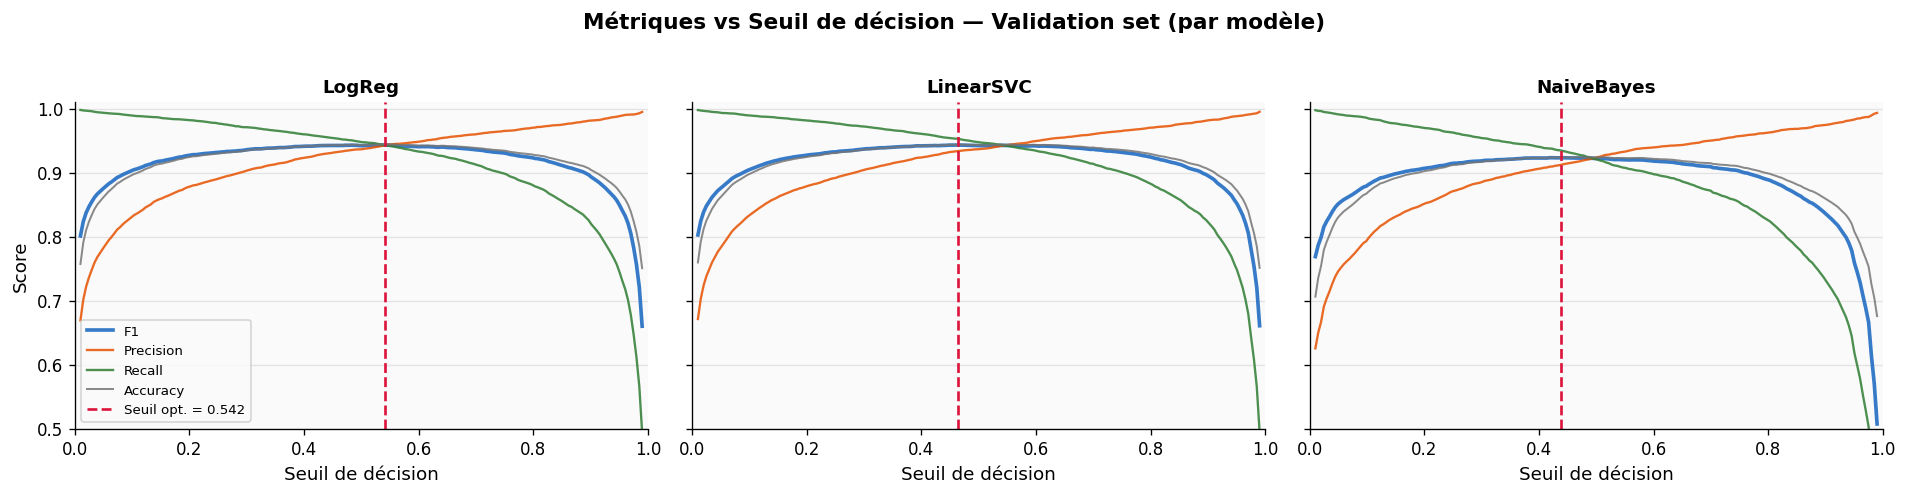

In [54]:
# ============================================================
#  SECTION 7 — OPTIMISATION DU SEUIL PAR MODÈLE
#
#  Règle absolue : le seuil s'optimise sur la VALIDATION,
#  jamais sur le test (data leakage sinon).
#
#  On cherche le seuil qui maximise le F1 sur X_val.
#  Chaque modèle a son propre seuil optimal car leurs
#  distributions de probabilités calibrées diffèrent.
# ============================================================

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score


def optimize_threshold_f1(
    model: CalibratedClassifierCV,
    X_val: pd.Series,
    y_val: pd.Series,
    n_points: int = 200,
) -> tuple[float, pd.DataFrame]:
    """
    Cherche le seuil maximisant le F1 sur le jeu de validation.

    Returns
    -------
    best_threshold : float — seuil optimal
    df             : DataFrame des métriques pour chaque seuil testé
    """
    y_proba    = model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.01, 0.99, n_points)

    records = []
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        records.append({
            "threshold": t,
            "f1":        f1_score(y_val, y_pred_t, zero_division=0),
            "precision": precision_score(y_val, y_pred_t, zero_division=0),
            "recall":    recall_score(y_val, y_pred_t, zero_division=0),
            "accuracy":  accuracy_score(y_val, y_pred_t),
        })

    df       = pd.DataFrame(records)
    best_t   = float(df.loc[df["f1"].idxmax(), "threshold"])
    best_f1  = df["f1"].max()

    return best_t, df, best_f1


# ── Optimisation pour chaque modèle ──────────────────────────
THRESHOLDS: dict[str, float] = {}
THRESHOLD_DFS: dict[str, pd.DataFrame] = {}

print("=" * 55)
print("  OPTIMISATION DES SEUILS — VALIDATION SET")
print("=" * 55)

for name, model in CALIBRATED_MODELS.items():
    best_t, df_t, best_f1_val = optimize_threshold_f1(model, X_val, y_val)
    THRESHOLDS[name]     = best_t
    THRESHOLD_DFS[name]  = df_t
    print(f"  {name:<14}  →  seuil = {best_t:.4f}  |  F1_val = {best_f1_val:.4f}")

# ── Visualisation des courbes seuil/métriques ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

PALETTE = {
    "f1":        ("#1565C0", 2.2),
    "precision": ("#E65100", 1.4),
    "recall":    ("#2E7D32", 1.4),
    "accuracy":  ("#757575", 1.2),
}

for ax, (name, df_t) in zip(axes, THRESHOLD_DFS.items()):
    for metric, (color, lw) in PALETTE.items():
        ax.plot(
            df_t["threshold"], df_t[metric],
            color=color, lw=lw,
            label=metric.capitalize(),
            alpha=0.85,
        )
    best_t = THRESHOLDS[name]
    ax.axvline(best_t, color="crimson", ls="--", lw=1.6,
               label=f"Seuil opt. = {best_t:.3f}")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Seuil de décision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, 1.01)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Score")
axes[0].legend(fontsize=8, loc="lower left")

fig.suptitle(
    "Métriques vs Seuil de décision — Validation set (par modèle)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "threshold_optimization_all_models.png", bbox_inches="tight")
plt.show()

In [55]:
# ============================================================
#  SECTION 8 — ÉVALUATION FINALE SUR LE TEST SET
#
#  C'est ici que la comparaison est définitive.
#  Règles respectées :
#  - Chaque modèle utilise SON seuil optimal (trouvé sur val)
#  - Évaluation sur le test set JAMAIS vu pendant l'optimisation
#  - Métriques identiques pour tous : F1, Accuracy, Precision,
#    Recall, ROC AUC
# ============================================================

from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay,
)


def full_evaluation(
    name: str,
    model: CalibratedClassifierCV,
    X_test: pd.Series,
    y_test: pd.Series,
    threshold: float,
    study_obj=None,
) -> dict:
    """
    Évalue complètement un modèle calibré sur le test set.

    Returns
    -------
    dict complet des métriques + métadonnées
    """
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)

    result = {
        "model":     name,
        "threshold": round(threshold, 6),
        "accuracy":  round(accuracy_score(y_test, y_pred),  4),
        "f1":        round(f1_score(y_test, y_pred),         4),
        "precision": round(precision_score(y_test, y_pred),  4),
        "recall":    round(recall_score(y_test, y_pred),     4),
        "roc_auc":   round(roc_auc_score(y_test, y_proba),  4),
        # Métriques intermédiaires pour diagnostic
        "y_pred":    y_pred,
        "y_proba":   y_proba,
        # Best CV score Optuna (si dispo)
        "optuna_f1_cv": round(study_obj.best_value, 4) if study_obj else None,
    }
    return result


# ── Évaluation des 3 modèles ──────────────────────────────────
STUDY_MAP = {
    "LogReg":    study,
    "LinearSVC": study_svc,
    "NaiveBayes": study_nb,
}

EVAL_RESULTS: list[dict] = []

print("=" * 60)
print("  ÉVALUATION FINALE — TEST SET")
print("=" * 60)

for name, model in CALIBRATED_MODELS.items():
    res = full_evaluation(
        name        = name,
        model       = model,
        X_test      = X_test,
        y_test      = y_test,
        threshold   = THRESHOLDS[name],
        study_obj   = STUDY_MAP[name],
    )
    EVAL_RESULTS.append(res)

    print(f"\n  ── {name} ──────────────────────────────")
    print(f"  Seuil décision  : {res['threshold']:.4f}")
    print(f"  Accuracy        : {res['accuracy']:.4f}")
    print(f"  F1-score        : {res['f1']:.4f}")
    print(f"  Precision       : {res['precision']:.4f}")
    print(f"  Recall          : {res['recall']:.4f}")
    print(f"  ROC AUC         : {res['roc_auc']:.4f}")
    if res["optuna_f1_cv"]:
        print(f"  Optuna F1 (CV)  : {res['optuna_f1_cv']:.4f}")
    print()
    print(classification_report(
        y_test, res["y_pred"],
        target_names=["Négatif", "Positif"],
    ))

  ÉVALUATION FINALE — TEST SET

  ── LogReg ──────────────────────────────
  Seuil décision  : 0.5419
  Accuracy        : 0.9439
  F1-score        : 0.9413
  Precision       : 0.9454
  Recall          : 0.9371
  ROC AUC         : 0.9873
  Optuna F1 (CV)  : 0.9396

              precision    recall  f1-score   support

     Négatif       0.94      0.95      0.95     10408
     Positif       0.95      0.94      0.94      9592

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000


  ── LinearSVC ──────────────────────────────
  Seuil décision  : 0.4631
  Accuracy        : 0.9444
  F1-score        : 0.9424
  Precision       : 0.9359
  Recall          : 0.9490
  ROC AUC         : 0.9874
  Optuna F1 (CV)  : 0.9403

              precision    recall  f1-score   support

     Négatif       0.95      0.94      0.95     10408
     Positif       0.94      0.95      0.94      9592

    acc

In [56]:
# ============================================================
#  SECTION 9 — TABLEAU COMPARATIF PROFESSIONNEL
# ============================================================

# ── Construction du DataFrame propre ─────────────────────────
compare_cols = ["model", "accuracy", "f1", "precision",
                "recall", "roc_auc", "optuna_f1_cv", "threshold"]

results_df = (
    pd.DataFrame([{k: r[k] for k in compare_cols} for r in EVAL_RESULTS])
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

# Ajout du rang et du delta vs meilleur
results_df.insert(0, "rang", results_df.index + 1)
best_f1 = results_df["f1"].iloc[0]
results_df["Δ F1 vs best"] = (results_df["f1"] - best_f1).round(4)

print("\n" + "=" * 70)
print("  COMPARAISON FINALE DES MODÈLES BASELINE (TEST SET)")
print("=" * 70)

metric_cols = ["accuracy", "f1", "precision", "recall",
               "roc_auc", "optuna_f1_cv", "Δ F1 vs best"]

styled = (
    results_df.style
    .format({c: "{:.4f}" for c in metric_cols})
    .background_gradient(subset=["f1", "roc_auc"], cmap="Blues")
    .background_gradient(subset=["Δ F1 vs best"], cmap="RdYlGn_r")
    .bar(subset=["accuracy"], color="#BBDEFB", vmin=0.8, vmax=1.0)
    .set_properties(**{"text-align": "center"})
    .set_caption(
        "Comparaison des modèles optimisés (Optuna) — calibrés — seuil optimal | Test set"
    )
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "13px"),
                   ("font-weight", "bold"),
                   ("text-align", "left")]},
        {"selector": "th",
         "props": [("background-color", "#E3F2FD"),
                   ("font-weight", "bold")]},
    ])
    .highlight_max(subset=["f1", "accuracy", "roc_auc"],
                   color="#C8E6C9")
    .highlight_min(subset=["f1", "accuracy", "roc_auc"],
                   color="#FFCDD2")
)

display(styled)

# ── Sauvegarde CSV ────────────────────────────────────────────
results_df.drop(columns=["Δ F1 vs best"]).to_csv(
    METRICS_DIR / "baseline_comparison_final.csv", index=False
)
print(f"\n CSV sauvegardé → {METRICS_DIR / 'baseline_comparison_final.csv'}")


  COMPARAISON FINALE DES MODÈLES BASELINE (TEST SET)


,rang,model,accuracy,f1,precision,recall,roc_auc,optuna_f1_cv,threshold,Δ F1 vs best
0,1,LinearSVC,0.9444,0.9424,0.9359,0.9490,0.9874,0.9403,0.463065,0.0000
1,2,LogReg,0.9439,0.9413,0.9454,0.9371,0.9873,0.9396,0.541859,-0.0011
2,3,NaiveBayes,0.9247,0.9226,0.9100,0.9356,0.9777,0.9212,0.438442,-0.0198



 CSV sauvegardé → /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine/reports/metrics/baseline_comparison_final.csv


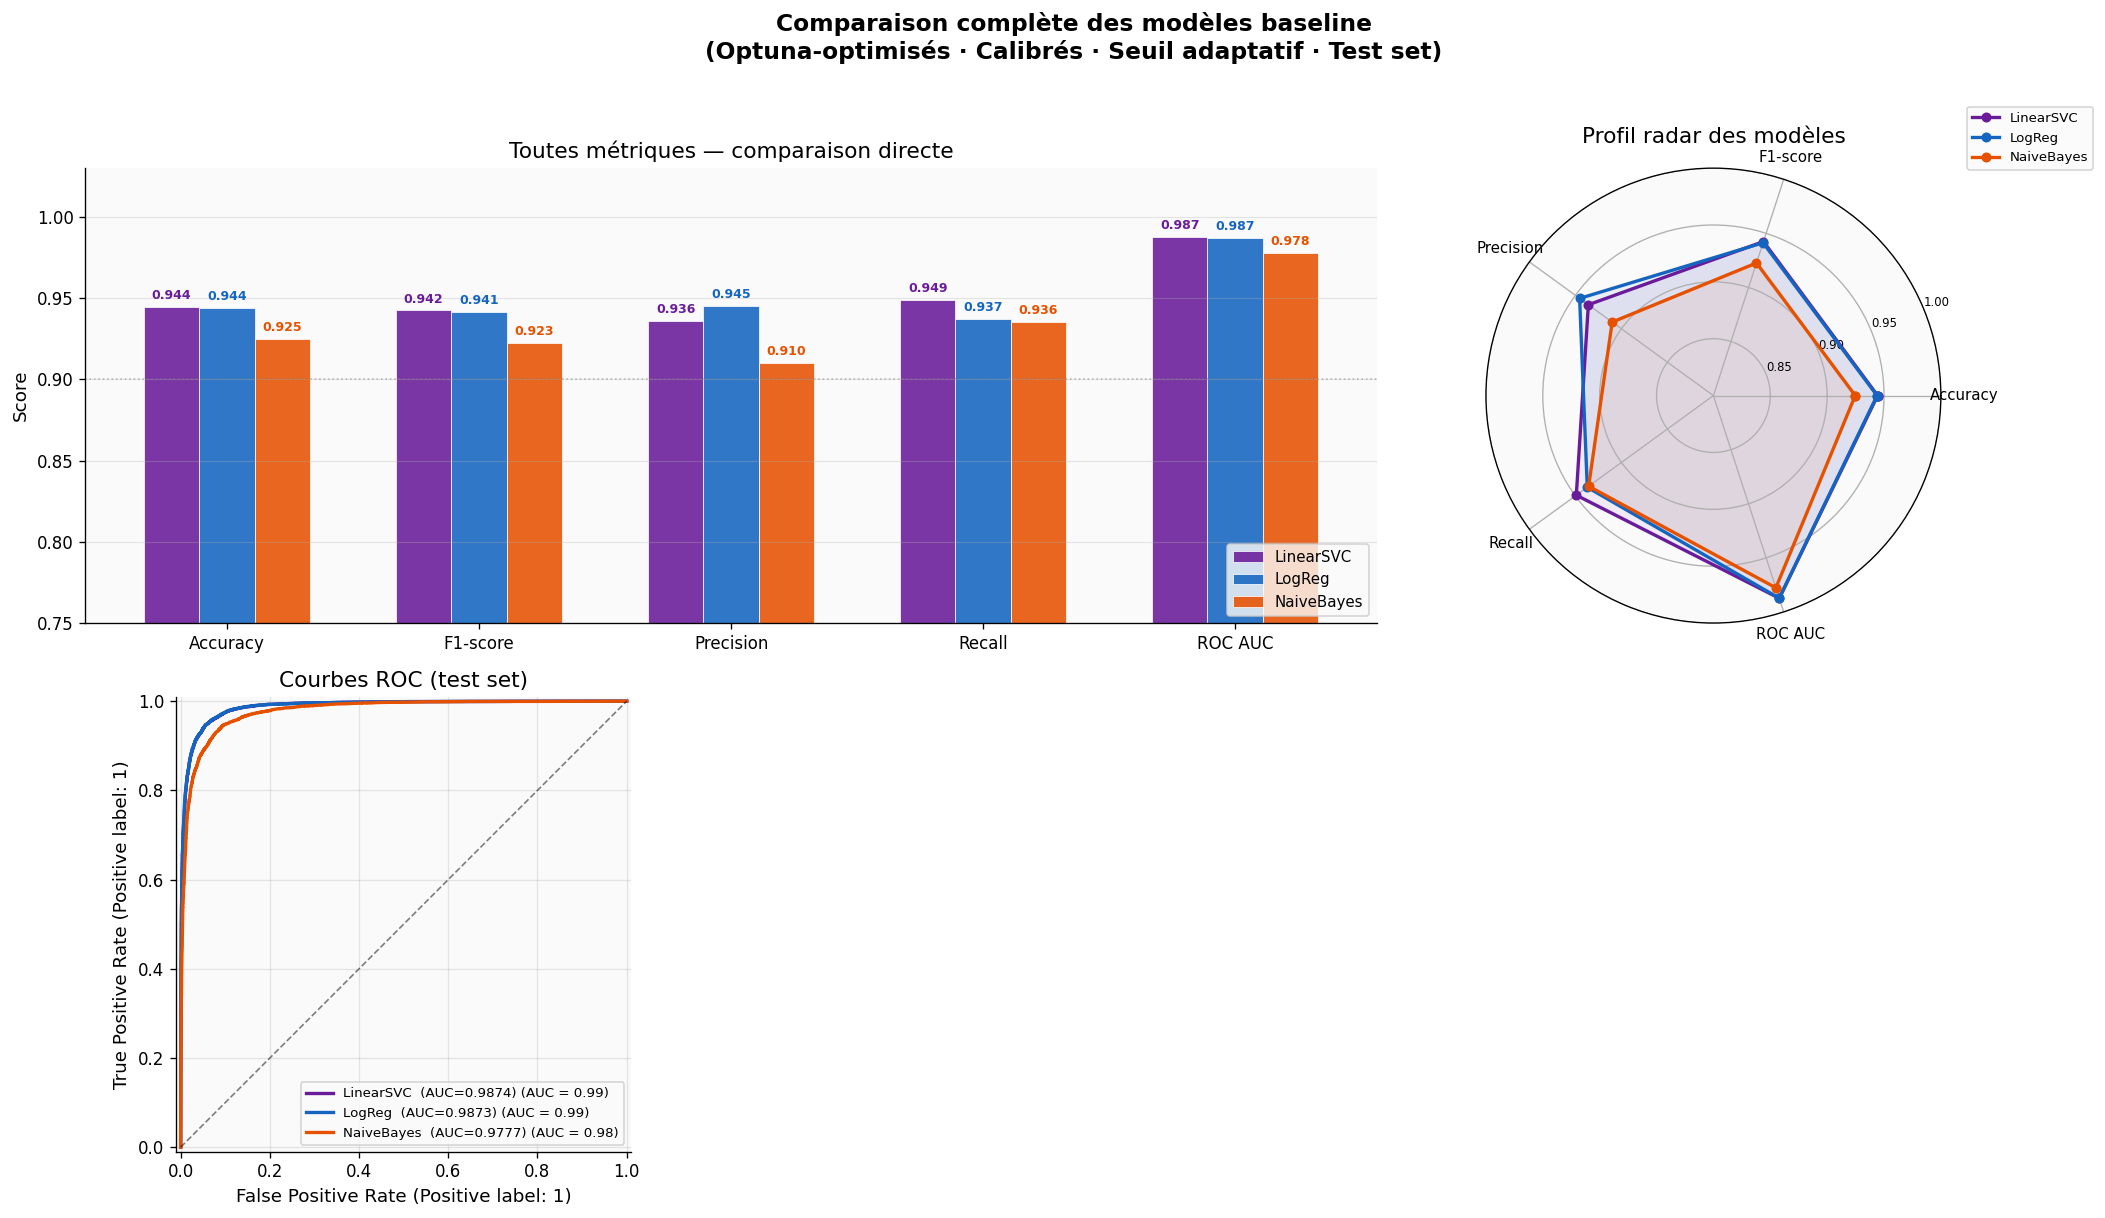

 Figure sauvegardée → /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine/reports/figures/baseline_full_comparison.png


In [58]:
# ============================================================
#  SECTION 10 — VISUALISATIONS COMPARATIVES
# ============================================================

MODEL_COLORS = {
    "LogReg":    "#1565C0",
    "LinearSVC": "#6A1B9A",
    "NaiveBayes":"#E65100",
}

metric_labels = {
    "accuracy":  "Accuracy",
    "f1":        "F1-score",
    "precision": "Precision",
    "recall":    "Recall",
    "roc_auc":   "ROC AUC",
}

fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    "Comparaison complète des modèles baseline\n"
    "(Optuna-optimisés · Calibrés · Seuil adaptatif · Test set)",
    fontsize=14, fontweight="bold", y=1.01,
)

# ── 10.1 Grouped barplot toutes métriques ────────────────────
ax1 = fig.add_subplot(2, 3, (1, 2))

metrics_plot = ["accuracy", "f1", "precision", "recall", "roc_auc"]
n_metrics    = len(metrics_plot)
n_models     = len(results_df)
bar_width    = 0.22
x            = np.arange(n_metrics)

for i, row in results_df.iterrows():
    offsets = x + i * bar_width - bar_width * (n_models - 1) / 2
    vals    = [row[m] for m in metrics_plot]
    color   = MODEL_COLORS.get(row["model"], "#607D8B")
    bars    = ax1.bar(offsets, vals, width=bar_width,
                      label=row["model"], color=color,
                      alpha=0.88, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom",
            fontsize=7.5, fontweight="bold",
            color=color,
        )

ax1.set_xticks(x)
ax1.set_xticklabels([metric_labels[m] for m in metrics_plot], fontsize=10)
ax1.set_ylabel("Score")
ax1.set_ylim(0.75, 1.03)
ax1.set_title("Toutes métriques — comparaison directe")
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(axis="y", alpha=0.3, lw=0.7)
ax1.axhline(0.9, color="gray", ls=":", lw=1, alpha=0.5)

# ── 10.2 Radar chart ─────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 3, projection="polar")

radar_metrics = ["accuracy", "f1", "precision", "recall", "roc_auc"]
angles        = np.linspace(0, 2 * np.pi, len(radar_metrics),
                            endpoint=False).tolist()
angles       += angles[:1]   # fermeture du polygone

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(
    [metric_labels[m] for m in radar_metrics], fontsize=9
)
ax2.set_ylim(0.80, 1.0)
ax2.set_yticks([0.85, 0.90, 0.95, 1.00])
ax2.set_yticklabels(["0.85", "0.90", "0.95", "1.00"], fontsize=7)
ax2.set_title("Profil radar des modèles", pad=15)

for _, row in results_df.iterrows():
    vals   = [row[m] for m in radar_metrics] + [row[radar_metrics[0]]]
    color  = MODEL_COLORS.get(row["model"], "#607D8B")
    ax2.plot(angles, vals, "o-", lw=2, label=row["model"],
             color=color, ms=5)
    ax2.fill(angles, vals, alpha=0.07, color=color)

ax2.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=8)

# ── 10.3 ROC Curves superposées ──────────────────────────────
ax3 = fig.add_subplot(2, 3, 4)

for _, row in results_df.iterrows():
    color = MODEL_COLORS.get(row["model"], "#607D8B")
    model = CALIBRATED_MODELS[row["model"]]
    y_proba = EVAL_RESULTS[results_df.index.get_loc(_)]["y_proba"]

    RocCurveDisplay.from_predictions(
        y_test, y_proba,
        name=f"{row['model']}  (AUC={row['roc_auc']:.4f})",
        ax=ax3, color=color, lw=2,
    )

ax3.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax3.set_title("Courbes ROC (test set)")
ax3.legend(fontsize=8, loc="lower right")
ax3.grid(alpha=0.3)


plt.tight_layout()
plt.savefig(
    REPORTS_DIR / "baseline_full_comparison.png",
    bbox_inches="tight", dpi=150,
)
plt.show()
print(f" Figure sauvegardée → {REPORTS_DIR / 'baseline_full_comparison.png'}")

  Analyse d'erreurs — Meilleur modèle : LinearSVC
   Seuil utilisé : 0.4631

  Total test      : 20,000
  Corrects        : 18,888  (94.4%)
  Faux Positifs   :    623  (3.1%)
  Faux Négatifs   :    489  (2.4%)

    FAUX POSITIFS — Négatif prédit Positif (les plus confiants)

  Proba(+) = 0.9984 | Vrai label = 0
  Texte    : Grosse fatigue est une bonne comédie.Le scénario est original,prenant et bien construit.La mise en scène,d'un niveau correcte,est classique, certaines scènes contiennent une légère touche de fantastique.Le rythme est soutenue(aucun temps mort).Bon pr...

  Proba(+) = 0.9982 | Vrai label = 0
  Texte    : Vraiment superbe !! merci j'ai bien rigolé ... avec un jeux d'acteur époustouflant ce film va vous emmener loin.

  Proba(+) = 0.9977 | Vrai label = 0
  Texte    : Ce petit road movies nous fait decouvrir la France sous son aspect gastronomique à vous faire saliver de gourmandise. Les yeux aussi prennent plaisir à decouvrir ou revoir notre patrimoine accompagné de co

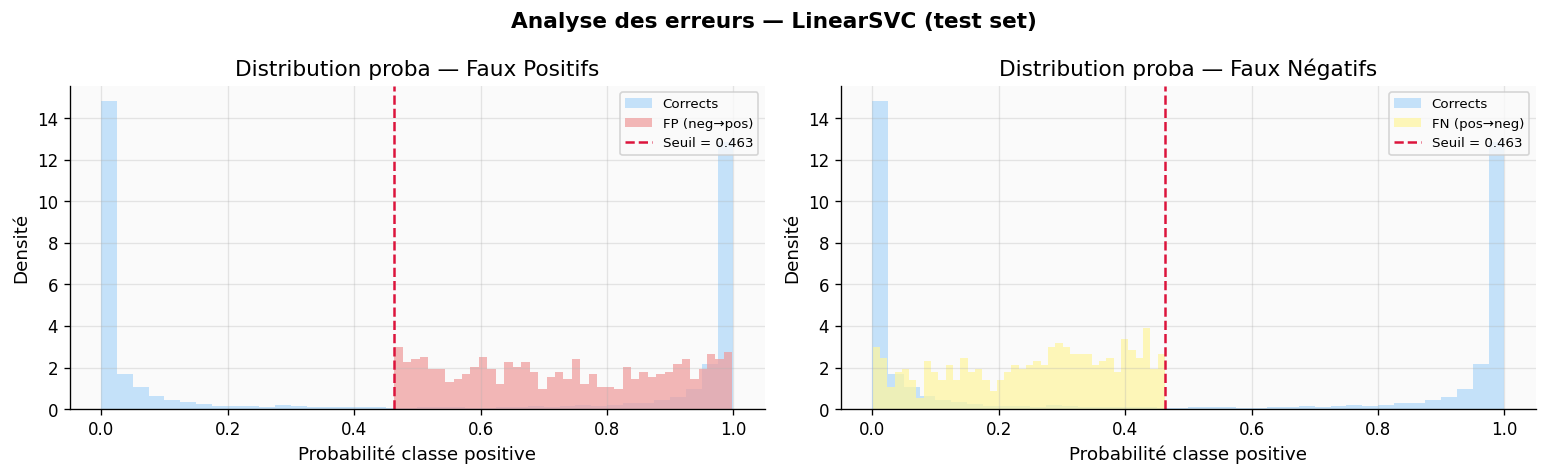


  Analyse d'erreurs sauvegardée → /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine/reports/metrics/error_analysis.parquet


In [64]:
# ============================================================
#  SECTION 11 — ANALYSE DES ERREURS (OBLIGATOIRE EN PROD)
#
#  On analyse les erreurs du MEILLEUR modèle.
#  Types d'erreurs :
#  - Faux positifs (FP) : critique négative classée positive
#  - Faux négatifs (FN) : critique positive classée négative
#
#  On inspecte les cas les plus "confiants" dans l'erreur
#  (proba très haute/basse mais mauvaise prédiction).
#  Cela révèle les limites du modèle et guide le fine-tuning.
# ============================================================

best_model_name = results_df.iloc[0]["model"]
best_model      = CALIBRATED_MODELS[best_model_name]
best_threshold  = THRESHOLDS[best_model_name]

best_res        = next(r for r in EVAL_RESULTS if r["model"] == best_model_name)
y_proba_best    = best_res["y_proba"]
y_pred_best     = best_res["y_pred"]

print(f"  Analyse d'erreurs — Meilleur modèle : {best_model_name}")
print(f"   Seuil utilisé : {best_threshold:.4f}\n")

# ── Construction du DataFrame d'analyse ──────────────────────
test_raw = pd.read_parquet(DATA_PATH / "test.parquet")

error_df = pd.DataFrame({
    "text_original":  test_raw["text"].values,
    "text_cleaned":   X_test,
    "label_true":     y_test,
    "label_pred":     y_pred_best,
    "proba_positive": y_proba_best,
    "correct":        y_test == y_pred_best,
})

error_df["error_type"] = "correct"
error_df.loc[
    (error_df["label_true"] == 0) & (error_df["label_pred"] == 1),
    "error_type"
] = "FP (neg→pos)"

error_df.loc[
    (error_df["label_true"] == 1) & (error_df["label_pred"] == 0),
    "error_type"
] = "FN (pos→neg)"

# ── Résumé ────────────────────────────────────────────────────
n_total  = len(error_df)
n_fp     = (error_df["error_type"] == "FP (neg→pos)").sum()
n_fn     = (error_df["error_type"] == "FN (pos→neg)").sum()
n_errors = n_fp + n_fn

print(f"  Total test      : {n_total:>6,}")
print(f"  Corrects        : {n_total - n_errors:>6,}  ({(n_total-n_errors)/n_total:.1%})")
print(f"  Faux Positifs   : {n_fp:>6,}  ({n_fp/n_total:.1%})")
print(f"  Faux Négatifs   : {n_fn:>6,}  ({n_fn/n_total:.1%})")

# ── Top erreurs confiantes ────────────────────────────────────
TOP_N = 5

def show_confident_errors(df, error_type, sort_col, ascending):
    subset = (
        df[df["error_type"] == error_type]
        .sort_values(sort_col, ascending=ascending)
        .head(TOP_N)
    )
    label = "  FAUX POSITIFS — Négatif prédit Positif (les plus confiants)"
    if error_type == "FN (pos→neg)":
        label = "  FAUX NÉGATIFS — Positif prédit Négatif (les plus confiants)"

    print(f"\n{'='*65}")
    print(f"  {label}")
    print(f"{'='*65}")
    for _, row in subset.iterrows():
        print(f"\n  Proba(+) = {row['proba_positive']:.4f} | Vrai label = {int(row['label_true'])}")
        txt = row["text_original"]
        print(f"  Texte    : {txt[:250]}{'...' if len(txt) > 250 else ''}")

show_confident_errors(error_df, "FP (neg→pos)",
                      "proba_positive", ascending=False)
show_confident_errors(error_df, "FN (pos→neg)",
                      "proba_positive", ascending=True)

# ── Distribution des probabilités : erreurs vs corrects ───────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, error_type, color, title in zip(
    axes,
    ["FP (neg→pos)", "FN (pos→neg)"],
    ["#EF9A9A", "#FFF59D"],
    ["Faux Positifs", "Faux Négatifs"],
):
    correct_subset = error_df[error_df["correct"]]
    error_subset   = error_df[error_df["error_type"] == error_type]

    ax.hist(correct_subset["proba_positive"], bins=40,
            alpha=0.5, color="#90CAF9", label="Corrects", density=True)
    ax.hist(error_subset["proba_positive"],  bins=40,
            alpha=0.7, color=color, label=error_type, density=True)
    ax.axvline(best_threshold, color="crimson", ls="--", lw=1.5,
               label=f"Seuil = {best_threshold:.3f}")
    ax.set_xlabel("Probabilité classe positive")
    ax.set_ylabel("Densité")
    ax.set_title(f"Distribution proba — {title}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    f"Analyse des erreurs — {best_model_name} (test set)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "error_analysis_proba_dist.png", bbox_inches="tight")
plt.show()

# Sauvegarde pour audit
error_df.drop(columns=["y_pred"] if "y_pred" in error_df.columns else []).to_parquet(
    METRICS_DIR / "error_analysis.parquet", index=False
)
print(f"\n  Analyse d'erreurs sauvegardée → {METRICS_DIR / 'error_analysis.parquet'}")

In [65]:
# ============================================================
#  SECTION 12 — SAUVEGARDE PRODUCTION DES ARTEFACTS
#
#  Structure de sauvegarde :
#  models/baseline/
#    ├── model_logreg.joblib
#    ├── model_linearsvc.joblib
#    ├── model_naivebayes.joblib
#    ├── best_model.joblib          ← modèle sélectionné
#    ├── best_model_config.json     ← config complète reproductible
#    └── all_models_config.json     ← tout pour audit/comparaison
# ============================================================

SLUG = {"LogReg": "logreg", "LinearSVC": "linearsvc", "NaiveBayes": "naivebayes"}

# ── Sauvegarde individuelle ───────────────────────────────────
print("=" * 55)
print("  SAUVEGARDE DES ARTEFACTS")
print("=" * 55)

for name, model in CALIBRATED_MODELS.items():
    path = MODEL_DIR / f"model_{SLUG[name]}.joblib"
    joblib.dump(model, path)
    print(f"    {name:<14} → {path.name}")

# ── Config complète pour audit ────────────────────────────────
all_configs = {}
for name in CALIBRATED_MODELS:
    study_obj = STUDY_MAP[name]
    all_configs[name] = {
        "optuna_best_params": study_obj.best_params,
        "optuna_best_f1_cv":  round(study_obj.best_value, 6),
        "threshold":          round(THRESHOLDS[name], 6),
        "test_metrics": {
            k: v
            for r in EVAL_RESULTS if r["model"] == name
            for k, v in r.items()
            if k not in ("y_pred", "y_proba", "model")
        },
    }

with open(METRICS_DIR / "all_models_config.json", "w", encoding="utf-8") as f:
    json.dump(all_configs, f, indent=2, ensure_ascii=False, default=str)
print(f"\n    Config complète → {METRICS_DIR / 'all_models_config.json'}")

# ── Sélection et sauvegarde du meilleur modèle ───────────────
best_name   = results_df.iloc[0]["model"]
best_model  = CALIBRATED_MODELS[best_name]
best_thresh = THRESHOLDS[best_name]
best_study  = STUDY_MAP[best_name]

joblib.dump(best_model, MODEL_DIR / "best_model.joblib")

best_config = {
    "selected_model":      best_name,
    "selection_criterion": "F1-score (test set)",
    "version":             "1.0.0",
    "threshold":           round(best_thresh, 6),
    "optuna_params":       best_study.best_params,
    "optuna_f1_cv":        round(best_study.best_value, 6),
    "test_metrics": {
        k: v
        for r in EVAL_RESULTS if r["model"] == best_name
        for k, v in r.items()
        if k not in ("y_pred", "y_proba", "model")
    },
    "seed": SEED,
}

with open(MODEL_DIR / "best_model_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False, default=str)

# ── Récapitulatif final ───────────────────────────────────────
best_row = results_df.iloc[0]
print(f"\n{'='*60}")
print(f"     MODÈLE SÉLECTIONNÉ : {best_name}")
print(f"{'='*60}")
print(f"  F1-score   : {best_row['f1']:.4f}")
print(f"  Accuracy   : {best_row['accuracy']:.4f}")
print(f"  Precision  : {best_row['precision']:.4f}")
print(f"  Recall     : {best_row['recall']:.4f}")
print(f"  ROC AUC    : {best_row['roc_auc']:.4f}")
print(f"  Seuil opt. : {best_thresh:.4f}")
print(f"\n  Fichiers produits dans models/baseline/ :")
for f in sorted(MODEL_DIR.glob("*")):
    print(f"   · {f.name}  ({f.stat().st_size / 1024:.0f} KB)")
print(f"\n   Baseline validé — prêt pour la phase CamemBERT.")

  SAUVEGARDE DES ARTEFACTS
    LogReg         → model_logreg.joblib
    LinearSVC      → model_linearsvc.joblib
    NaiveBayes     → model_naivebayes.joblib

    Config complète → /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine/reports/metrics/all_models_config.json

     MODÈLE SÉLECTIONNÉ : LinearSVC
  F1-score   : 0.9424
  Accuracy   : 0.9444
  Precision  : 0.9359
  Recall     : 0.9490
  ROC AUC    : 0.9874
  Seuil opt. : 0.4631

  Fichiers produits dans models/baseline/ :
   · .gitkeep  (0 KB)
   · ComplementNB.joblib  (7451 KB)
   · LinearSVC.joblib  (6672 KB)
   · LogisticRegression.joblib  (4326 KB)
   · best_model.joblib  (28308 KB)
   · best_model_config.json  (1 KB)
   · model_linearsvc.joblib  (28308 KB)
   · model_logreg.joblib  (28309 KB)
   · model_naivebayes.joblib  (63857 KB)

   Baseline validé — prêt pour la phase CamemBERT.
